# PPE Compliance Checker — Training (Google Colab)

**ITAI 1378 midterm.** This notebook covers the full workflow:
download the dataset → train YOLO11 → evaluate → run the compliance demo → zip the results.

## How to run (3 steps)
1. **Runtime → Change runtime type → T4 GPU → Save.**
2. **Runtime → Run all** (or press each cell's play button top to bottom).
3. When it finishes, the last cell **downloads `ppe_results.zip`** with your trained model, metrics, and demo images.

Training takes roughly 15–25 minutes on a free T4 GPU. 

## 1 · Install + GPU check

In [1]:
!pip install -q ultralytics
import torch, ultralytics
ultralytics.checks()
print('GPU available:', torch.cuda.is_available())
assert torch.cuda.is_available(), 'No GPU! Do step 1: Runtime > Change runtime type > T4 GPU.'

Ultralytics 8.4.92 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 46.7/112.6 GB disk)
GPU available: True


## 2 · Train YOLO11 on the Construction-PPE dataset
The dataset (1,132 train / 143 val / 141 test images, 178 MB) auto-downloads on the first run. Classes: `helmet, gloves, vest, boots, goggles, none, Person, no_helmet, no_goggle, no_gloves, no_boots`.

*To go faster for a first pass, set `MODEL='yolo11n.pt'` and `EPOCHS=20`.*

In [2]:
from ultralytics import YOLO

MODEL  = 'yolo11s.pt'   # 's' = good accuracy/speed; use 'yolo11n.pt' for a faster first pass
EPOCHS = 40
IMGSZ  = 640

model = YOLO(MODEL)
results = model.train(
    data='construction-ppe.yaml',
    epochs=EPOCHS, imgsz=IMGSZ, batch=16,
    patience=15, name='ppe', plots=True
)
RUN_DIR = results.save_dir           # e.g. runs/detect/ppe
print('Training outputs saved to:', RUN_DIR)

Ultralytics 8.4.92 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=construction-ppe.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=40, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=ppe, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patien

## 3 · Evaluate — real metrics on the held-out set

In [3]:
metrics = model.val()
print(f'mAP@50      : {metrics.box.map50:.3f}')
print(f'mAP@50-95   : {metrics.box.map:.3f}')
print(f'mean precision: {metrics.box.mp:.3f}   mean recall: {metrics.box.mr:.3f}')
# Per-class mAP@50
for i, name in model.names.items():
    try:
        print(f'  {name:12s} mAP@50 = {metrics.box.maps[i]:.3f}')
    except Exception:
        pass

Ultralytics 8.4.92 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 101 layers, 9,417,057 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2818.2±1196.4 MB/s, size: 181.3 KB)
val: Scanning /content/datasets/construction-ppe/labels/val.cache... 143 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 143/143 50.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 9/9 2.1it/s 4.2s
                   all        143       1172      0.663      0.585      0.608      0.302
                helmet        107        201      0.825      0.811      0.803      0.427
                gloves         68        136      0.858      0.779      0.826      0.392
                  vest        109        171       0.85       0.83       0.85      0.532
                 boots         64        151      0.759      0.732      0.799       0.45
               goggles       

## 4 · Show training curves + confusion matrix

results.png


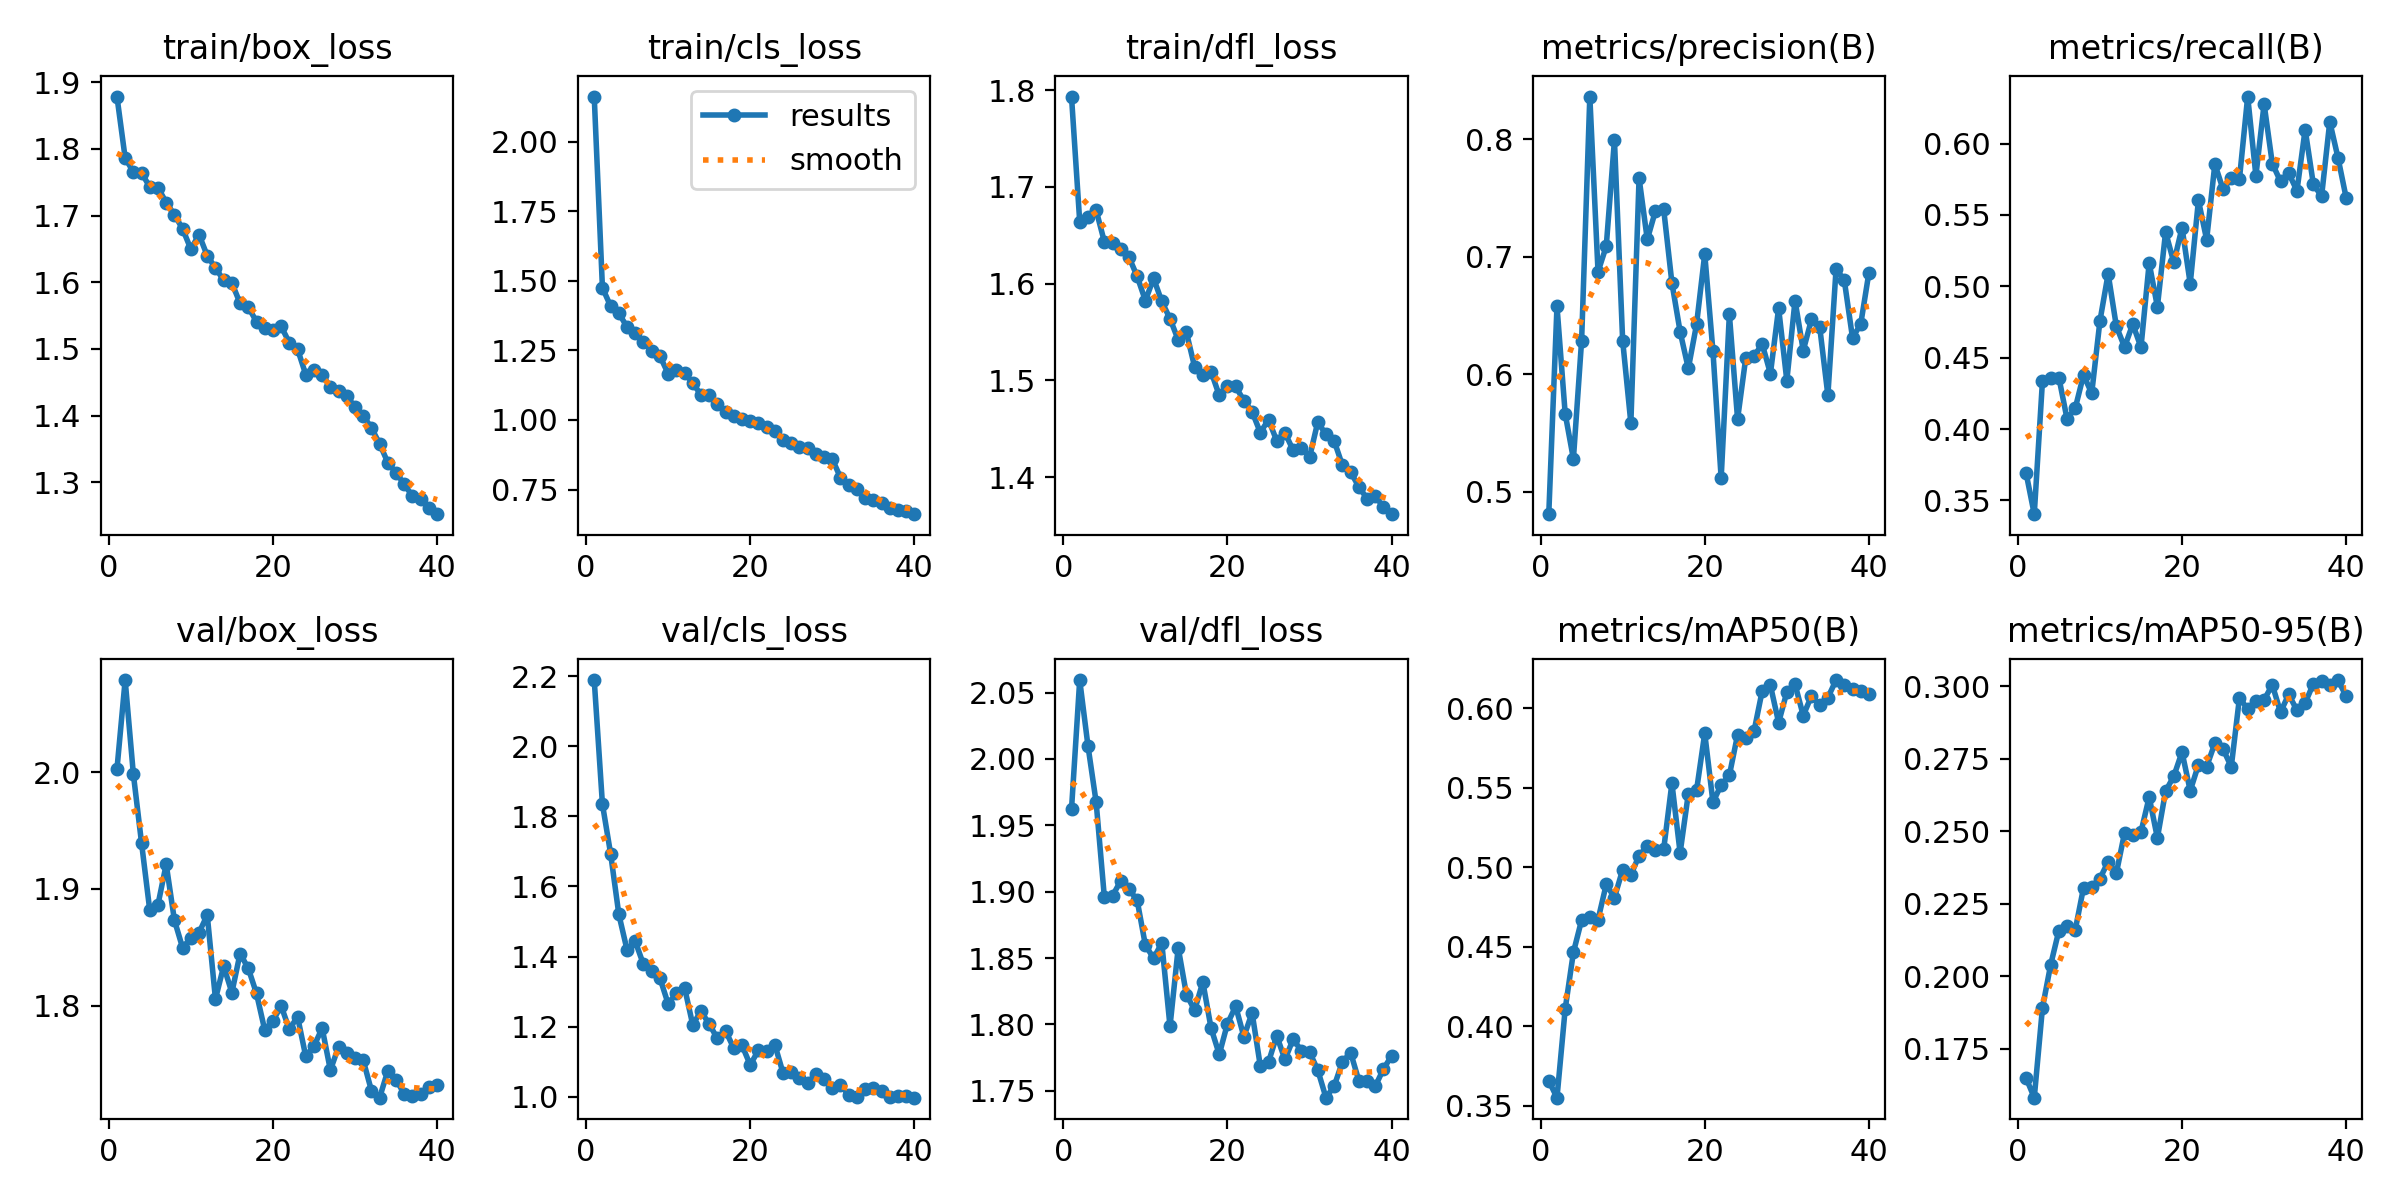

confusion_matrix.png


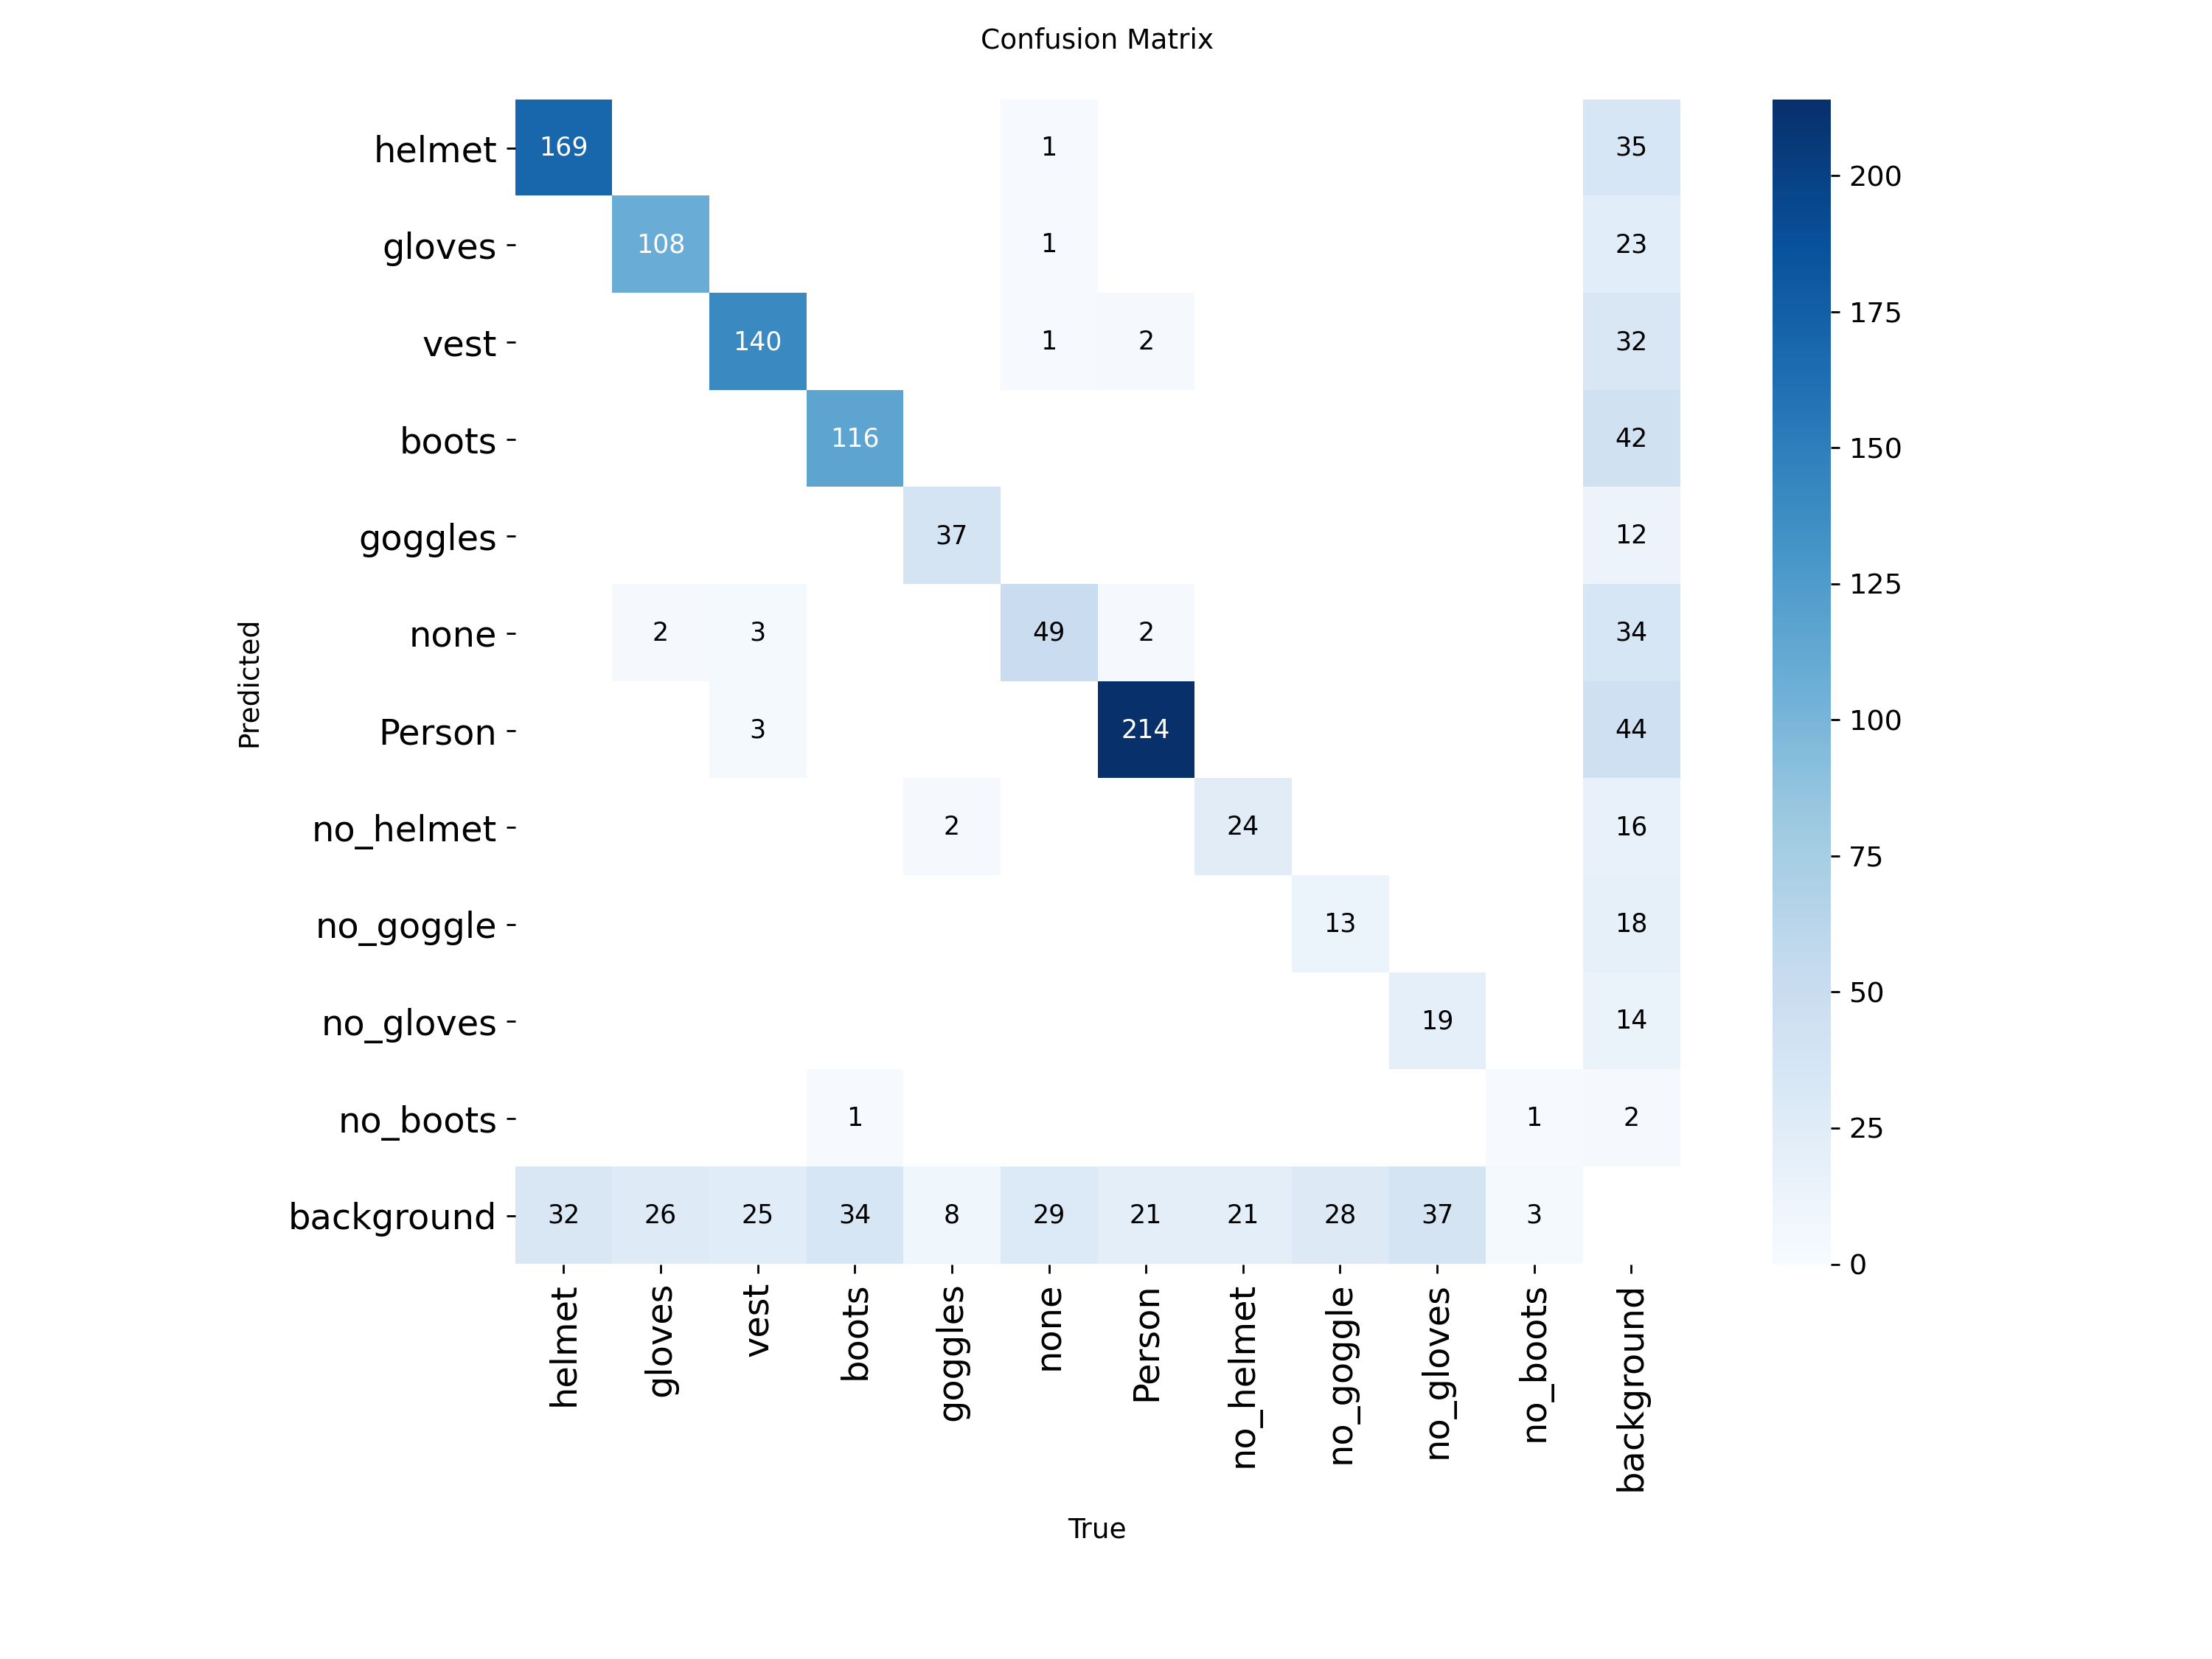

val_batch0_pred.jpg


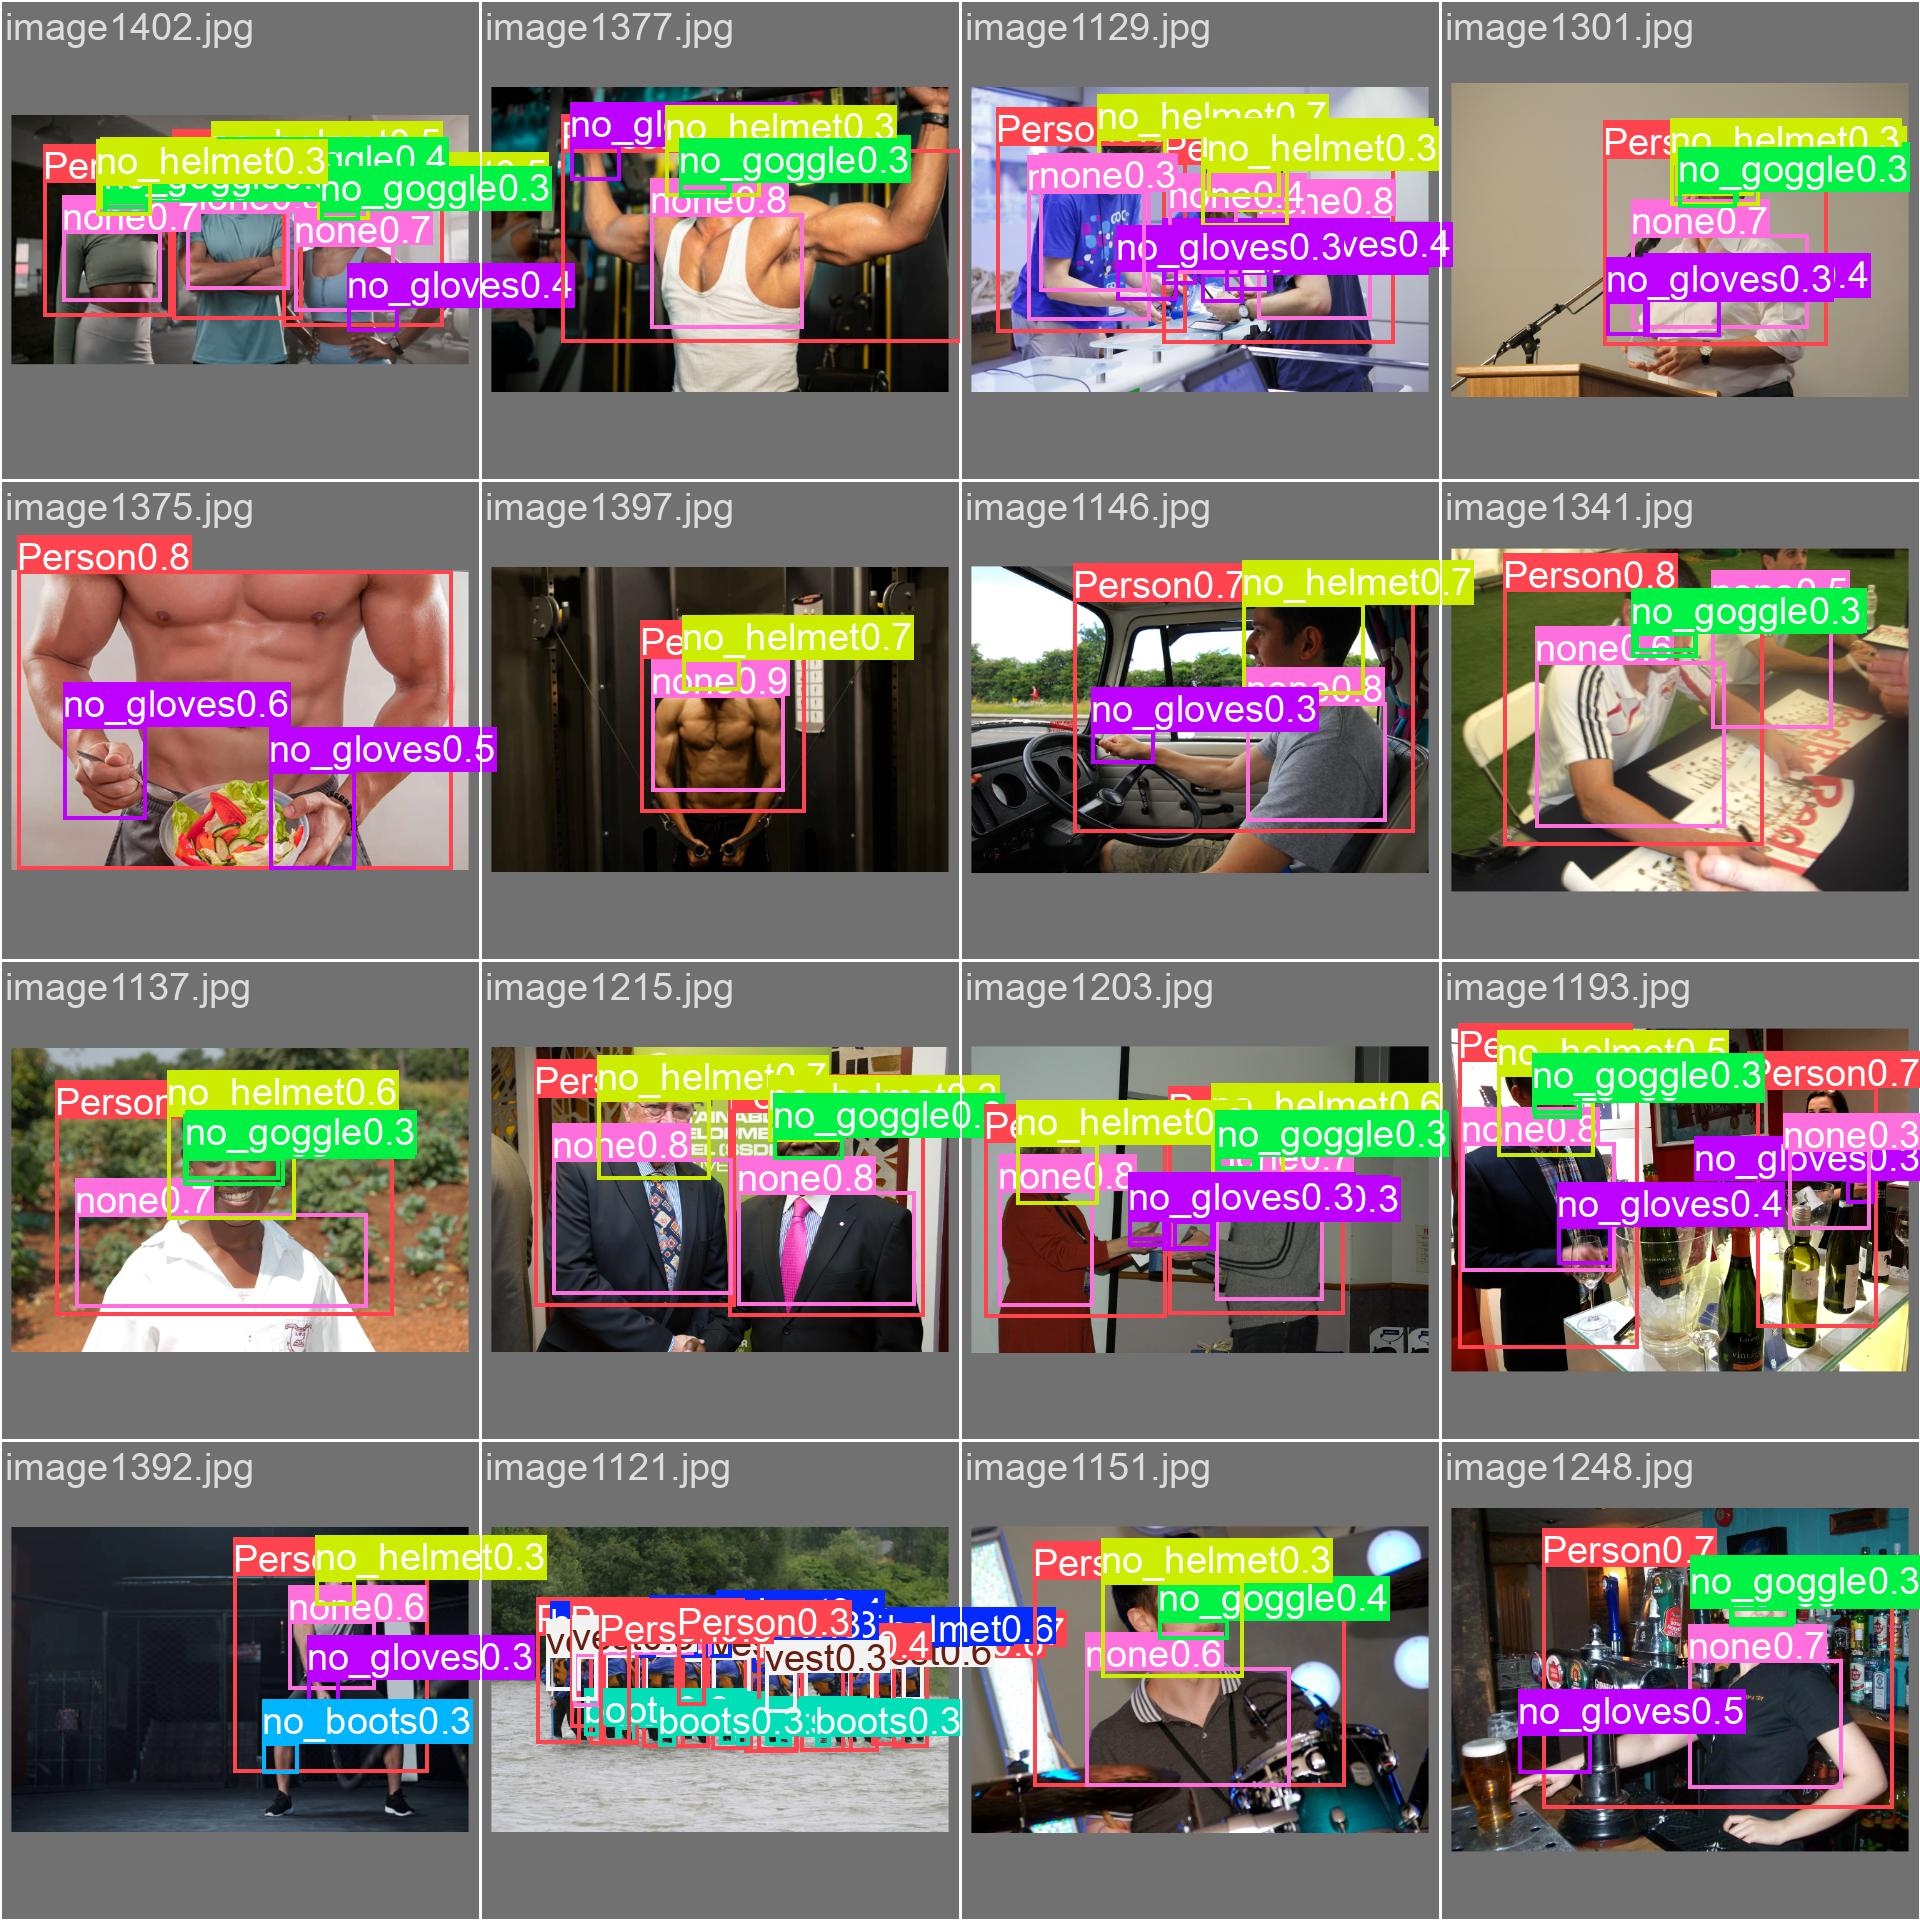

In [4]:
from IPython.display import Image, display
import os
for f in ['results.png', 'confusion_matrix.png', 'val_batch0_pred.jpg']:
    p = os.path.join(RUN_DIR, f)
    if os.path.exists(p):
        print(f); display(Image(filename=p, width=780))

## 5 · Compliance demo — label each worker Compliant / Non-compliant
Rule per person: **non-compliant** if a `no_helmet` or `no_goggle` box overlaps them, or if no `vest` overlaps them; **compliant** otherwise.

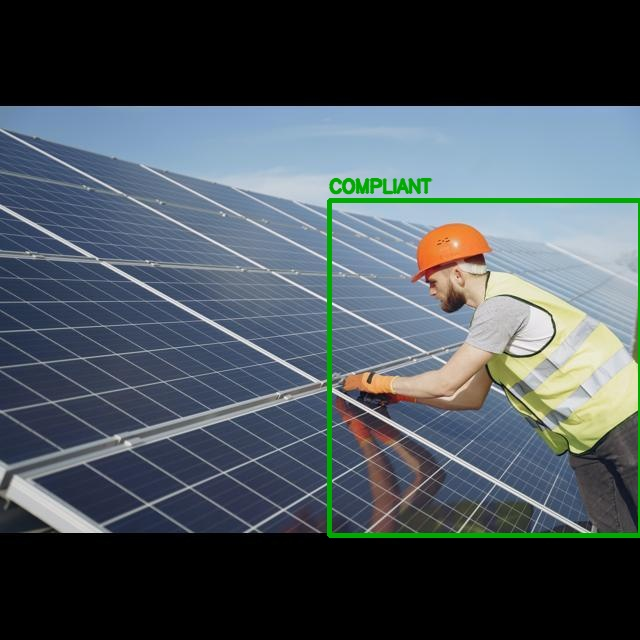

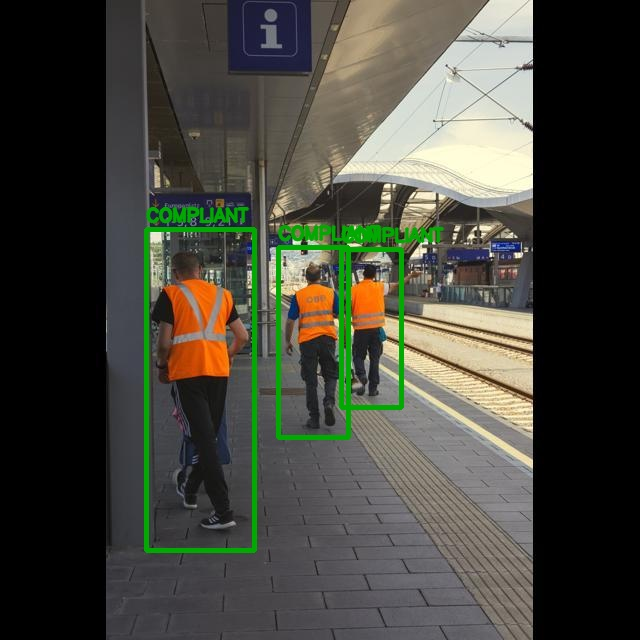

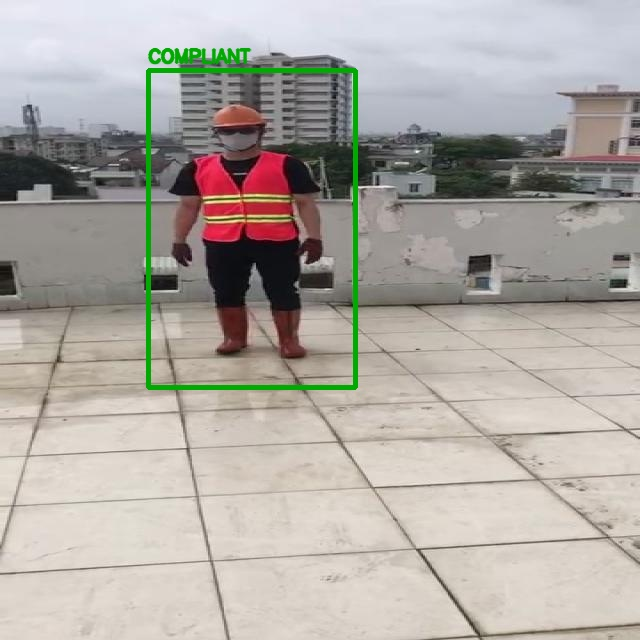

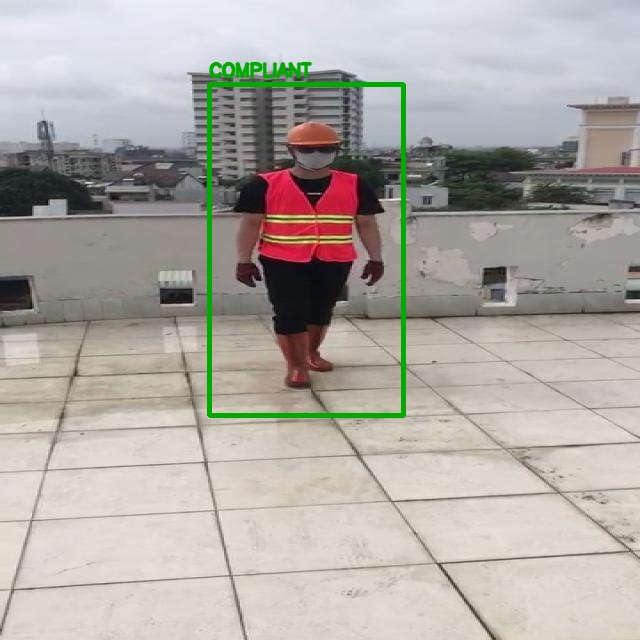

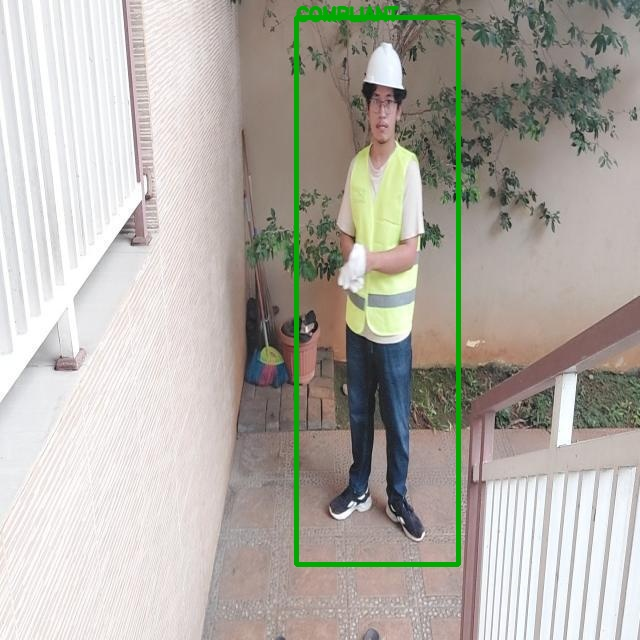

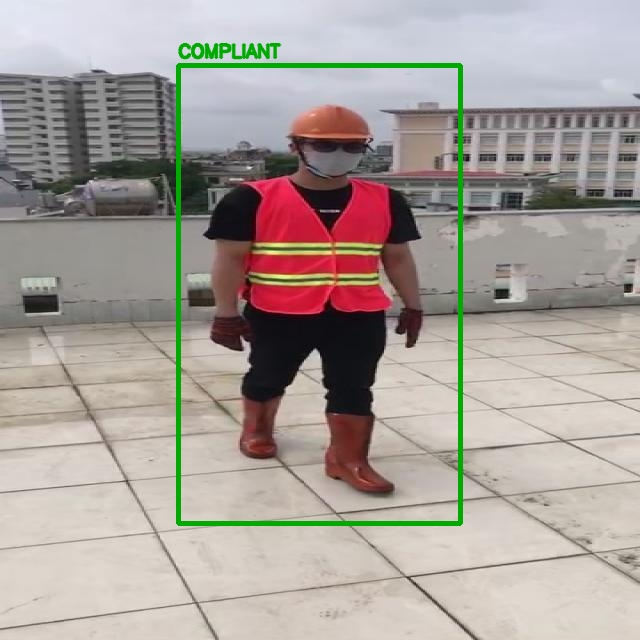

Saved 6 annotated images to /content/compliance_out


In [5]:
import cv2, glob, numpy as np
from ultralytics.utils import SETTINGS

best = os.path.join(RUN_DIR, 'weights', 'best.pt')
det  = YOLO(best)
names = det.names

def center_in(box, person):
    cx, cy = (box[0]+box[2])/2, (box[1]+box[3])/2
    return person[0] <= cx <= person[2] and person[1] <= cy <= person[3]

def annotate(img_path, conf=0.35):
    img = cv2.imread(img_path)
    r = det(img_path, conf=conf, verbose=False)[0]
    dets = [(names[int(c)], list(map(float, b))) for c, b in zip(r.boxes.cls, r.boxes.xyxy)]
    persons = [b for n, b in dets if n.lower() == 'person']
    others  = [(n, b) for n, b in dets if n.lower() != 'person']
    if not persons:                      # no person box: judge image-level on violation labels
        bad = [n for n, _ in others if n in ('no_helmet','no_goggle')]
        persons = [[0,0,img.shape[1],img.shape[0]]]
    for p in persons:
        near = [n for n, b in others if center_in(b, p)]
        has_vest = any(n == 'vest' for n in near)
        violations = [n for n in near if n in ('no_helmet','no_goggle')]
        if not has_vest: violations.append('no_vest')
        ok = len(violations) == 0
        color = (0,170,0) if ok else (0,0,220)
        label = 'COMPLIANT' if ok else 'NON-COMPLIANT: ' + ','.join(v.replace('no_','no ') for v in violations)
        x1,y1,x2,y2 = map(int, p)
        cv2.rectangle(img,(x1,y1),(x2,y2),color,3)
        cv2.putText(img,label,(x1,max(20,y1-8)),cv2.FONT_HERSHEY_SIMPLEX,0.6,color,2,cv2.LINE_AA)
    return img

# Run on a handful of test images
test_dir = os.path.join(SETTINGS['datasets_dir'], 'construction-ppe', 'images', 'test')
imgs = sorted(glob.glob(os.path.join(test_dir, '*')))[:6]
os.makedirs('/content/compliance_out', exist_ok=True)
for ip in imgs:
    out = annotate(ip)
    op = os.path.join('/content/compliance_out', os.path.basename(ip))
    cv2.imwrite(op, out)
    display(Image(filename=op, width=560))
print('Saved', len(imgs), 'annotated images to /content/compliance_out')

## 6 · Zip + download all results

In [6]:
import shutil, os
os.makedirs('/content/ppe_results', exist_ok=True)
# weights
shutil.copy(os.path.join(RUN_DIR,'weights','best.pt'), '/content/ppe_results/best.pt')
# metrics/plots
for f in ['results.png','results.csv','confusion_matrix.png','confusion_matrix_normalized.png','PR_curve.png','val_batch0_pred.jpg']:
    p=os.path.join(RUN_DIR,f)
    if os.path.exists(p): shutil.copy(p,'/content/ppe_results/')
# compliance demo images
shutil.copytree('/content/compliance_out','/content/ppe_results/compliance_out', dirs_exist_ok=True)
shutil.make_archive('/content/ppe_results','zip','/content/ppe_results')
print('Zipped. Downloading ppe_results.zip ...')
try:
    from google.colab import files; files.download('/content/ppe_results.zip')
except Exception as e:
    print('Download the file manually from the Files panel: /content/ppe_results.zip', e)

Zipped. Downloading ppe_results.zip ...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Outputs
- `best.pt` — your trained YOLO11 PPE model
- `results.png`, `results.csv` — training curves + raw metrics
- `confusion_matrix.png`, `PR_curve.png` — evaluation plots
- `compliance_out/` — sample images labeled Compliant / Non-compliant

The trained weights and evaluation plots are saved under `docs/results/`.